In [1]:
from xaikd import models, utils, datasets

from matplotlib import pyplot as plt 

import numpy as np

In [2]:
dataset = datasets.construct("imagenet-butterfly")

Linear(in_features=4096, out_features=1000, bias=True)

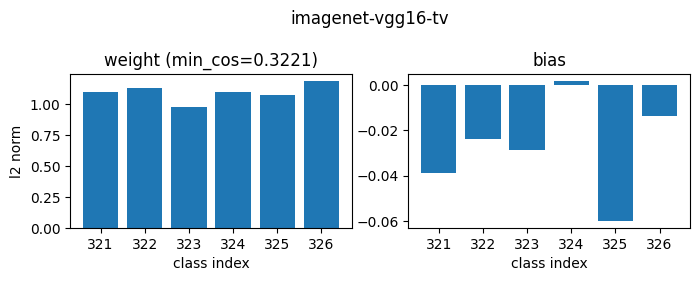

In [12]:
def viz_weight(model_name):

    
    model = models.get_trained_model(model_name)
    
    utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)
    
    last_layer = model.__last_layer
    
    weight = last_layer.weight.detach().numpy()
    
    normed_weight = weight / np.linalg.norm(weight, axis=1, keepdims=True)
    
    cosine = normed_weight @ normed_weight.T

    min_cosine = np.min(cosine)
    
    bias = last_layer.bias.detach().numpy()
        
    nc, _ = weight.shape
    
    plt.figure(figsize=(4*2, 2))
    plt.suptitle(model_name, y=1.2)
    
    plt.subplot(1, 2, 1)
    plt.title(f"weight (min_cos={min_cosine:.4f})")
    plt.ylabel("l2 norm")
    plt.xlabel("class index")
    plt.bar(
        range(nc),
        np.linalg.norm(weight, axis=1)
    )
    
    plt.xticks(range(nc), dataset.selected_classes)
    
    
    
    plt.subplot(1, 2, 2)
    plt.title("bias")
    plt.xlabel("class index")
    plt.bar(
        range(nc),
        bias
    )
    plt.xticks(range(nc), dataset.selected_classes)

    return last_layer

viz_weight("imagenet-vgg16-tv")

Linear(in_features=4096, out_features=1000, bias=True)

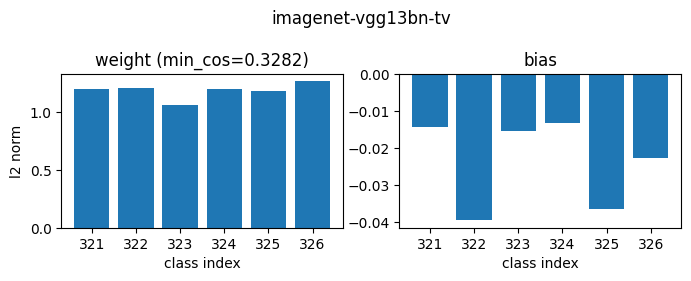

In [18]:
viz_weight("imagenet-vgg13bn-tv")

Linear(in_features=4096, out_features=1000, bias=True)

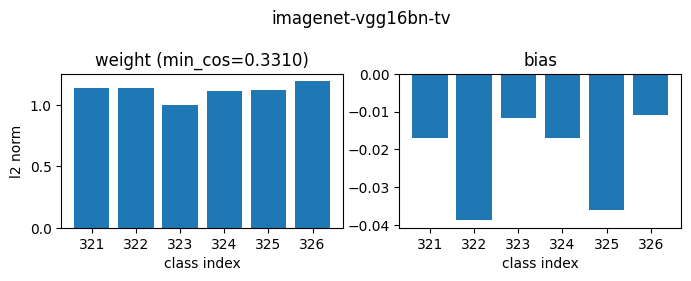

In [14]:
viz_weight("imagenet-vgg16bn-tv")

Linear(in_features=512, out_features=1000, bias=True)

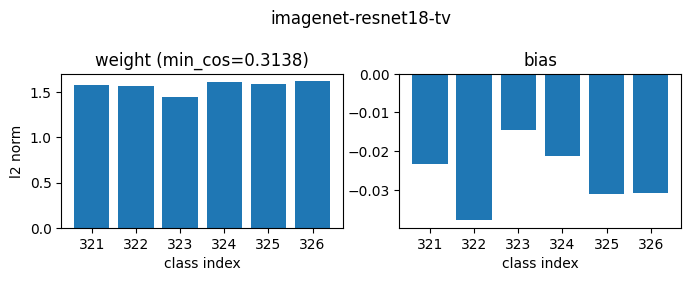

In [15]:
viz_weight("imagenet-resnet18-tv")

Linear(in_features=2048, out_features=1000, bias=True)

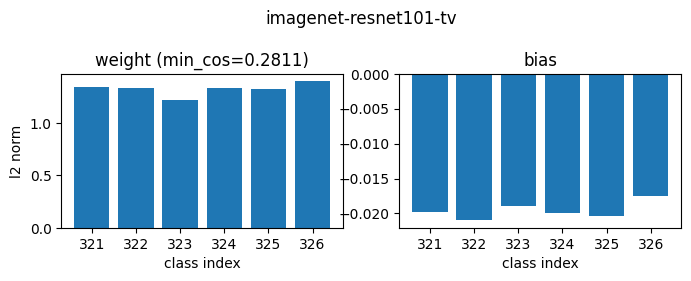

In [17]:
viz_weight("imagenet-resnet101-tv")

Linear(in_features=2048, out_features=1000, bias=True)

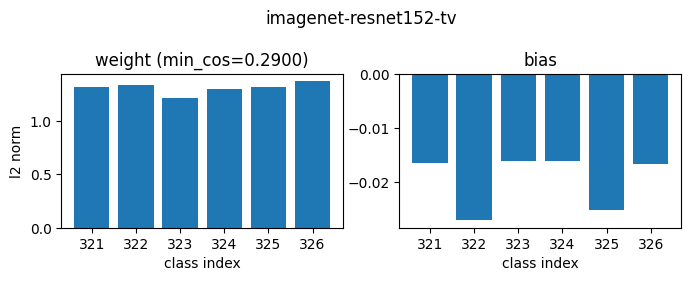

In [16]:
viz_weight("imagenet-resnet152-tv")